In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

In [87]:
df = pd.read_csv('Social_Network_Ads1.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [89]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


array([[<Axes: title={'center': 'User ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Purchased'}>]], dtype=object)

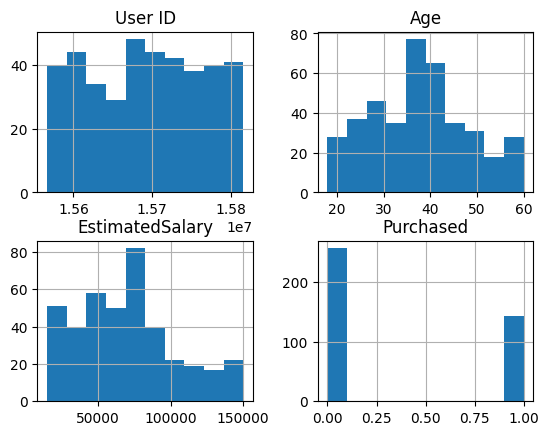

In [90]:
df.hist()

<Axes: >

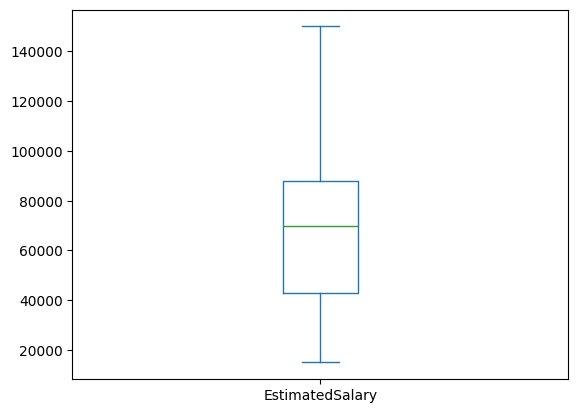

In [91]:
df['EstimatedSalary'].plot.box()
# plt.boxplot(df['EstimatedSalary'])

In [92]:
df.drop(['Gender','User ID'],axis=1,inplace=True)

x = df.drop('Purchased', axis=1)
y = df['Purchased']

In [93]:
print(x)
print(y)

     Age  EstimatedSalary
0     19            19000
1     35            20000
2     26            43000
3     27            57000
4     19            76000
..   ...              ...
395   46            41000
396   51            23000
397   50            20000
398   36            33000
399   49            36000

[400 rows x 2 columns]
0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64


In [94]:
x.shape
y.shape

(400,)

In [95]:
x_train,x_test,y_train,y_test = sk.model_selection.train_test_split(x,y,test_size=0.2,random_state=42)

In [96]:
print(x_train.shape)
print(x_test.shape)

(320, 2)
(80, 2)


In [97]:
std = sk.preprocessing.StandardScaler()
x_train = std.fit_transform(x_train)
x_test = std.fit_transform(x_test)

In [98]:
model = sk.linear_model.LogisticRegression()
model.fit(x_train,y_train)


LogisticRegression()

In [99]:
y_predict = model.predict(x_test)
print(y_predict)

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 0 1 1 0 0]


In [110]:
cm = sk.metrics.confusion_matrix(y_test,y_predict)
print(f"Confusion Matrix: \n{cm}")
print("----------------------------------------------------------")
print(f"Accuracy Score: {sk.metrics.accuracy_score(y_test,y_predict) * 100} %")
print("----------------------------------------------------------")
print(f"Classification Report: \n{sk.metrics.classification_report(y_test,y_predict)}")


Confusion Matrix: 
[[49  3]
 [ 8 20]]
----------------------------------------------------------
Accuracy Score: 86.25 %
----------------------------------------------------------
Classification Report: 
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        52
           1       0.87      0.71      0.78        28

    accuracy                           0.86        80
   macro avg       0.86      0.83      0.84        80
weighted avg       0.86      0.86      0.86        80



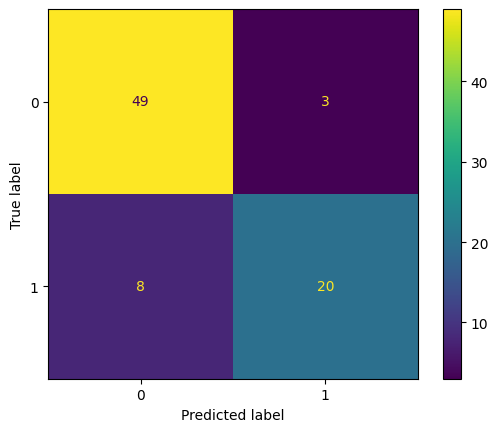

In [114]:
sk.metrics.ConfusionMatrixDisplay(cm).plot()